# SED Anatomy

_sed_anatomy

This notebook is a map from **wavelength to physics**: panchromatic plots use
the full forward model (IR re-radiation, radio, X-ray). **Optical spectroscopic
fitting** should use a narrower model—SSP starlight + **baked-in** nebular
(this grid’s ``wNE`` file) + Charlot–Fall attenuation only—so the likelihood
matches the data vector (extra components can drive NaNs or meaningless χ²).
**Spine path:** `notebooks/01_sed_anatomy.py`.

**Related:** SFH parametrization and stochastic-field theory — [`02_sfh_gallery.py`](02_sfh_gallery.py)
(especially §0). Mock SEDs from **known** tabulated SFHs (no `Parameters`) —
[`13_tabulated_sfh_to_mock_sed.py`](13_tabulated_sfh_to_mock_sed.py).

## Setup: imports and model configuration

In [1]:
import os
import sys
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message=".*BakedInBackend.*",
    category=UserWarning,
)

from tengri import (
    Fixed,
    Model,
    Observation,
    Parameters,
    SEDModel,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

# Locate ``notebooks/_plot_style.py`` and ``data/`` root (nbclient cwd is often wrong).
import importlib.util

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "sed_anatomy")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, setup_style

setup_style()

In [2]:
SSP_PATH = "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
ssp_data = load_ssp_data(SSP_PATH)


def _sfh_dust_kwargs():
    """Shared fixed galaxy: star-forming, moderate dust."""
    return dict(
        mean_sfh_type="tsnorm",
        sfh_tsnorm_log_peak_sfr=Fixed(1.2),
        sfh_tsnorm_peak_lbt_gyr=Fixed(4.0),
        sfh_tsnorm_width_gyr=Fixed(2.5),
        sfh_tsnorm_skew=Fixed(0.2),
        sfh_tsnorm_trunc=Fixed(6.0),
        met_logzsol=Fixed(0.0),
        dust_tau_bc=Fixed(1.0),
        dust_tau_diff=Fixed(0.3),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.05),
    )


# Inference-safe optical path: baked nebular in SSP, two-component attenuation only.
# (Do not add dust_emission / radio / xray when the data are optical pixels only.)
spec_baked_optical = Parameters(**_sfh_dust_kwargs(), nebular_ssp=True)

# Full physics for *visualization*: Draine & Li IR, radio + X-ray scalings
spec_full = Parameters(
    **_sfh_dust_kwargs(),
    nebular_ssp=True,
    dust_emission="draine_li2007",
    dust_T=Fixed(35.0),
    dust_qpah=Fixed(2.5),
    radio=True,
    xray=True,
    radio_q_ir=Fixed(2.64),
)
model_full = SEDModel(spec_full, ssp_data, observation=None)
params = spec_full.sample(jax.random.PRNGKey(42))

W0405 18:27:48.038926  560631 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## Section 1: X-ray to radio in one plot

`predict_spectrum` returns the **observed-frame** flux density
(erg/s/cm²/Hz) including distance and IGM handling inside the pipeline. The
curve includes stellar+nebular (from the SSP), dust attenuation, dust IR
re-radiation, and the empirical radio / X-ray extensions.

/Users/suchethacooray/Projects/diffsed/src/tengri/core/model.py:1274: UserWarning: Unrecognized parameter names passed to Model: ['dust_alpha_dl14']. These will be silently ignored. Did you mean one of: ['dust_Rv', 'dust_T', 'dust_alpha_dale', 'dust_alpha_mir', 'dust_beta_ir', 'dust_bump_strength', 'dust_delta', 'dust_eta_balance', 'dust_f_obscuration', 'dust_gamma_dl', 'dust_qpah', 'dust_slope', 'dust_tau_bc', 'dust_tau_diff', 'dust_umin', 'met_alpha_fe', 'met_logzsol', 'noise_dof', 'noise_frac_cal', 'radio_alpha_agn', 'radio_alpha_sf', 'radio_loudness', 'radio_q_ir', 'redshift', 'sfh_tsnorm_log_peak_sfr', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr', 'xray_alpha_ox', 'xray_gamma_agn']?
  p = self._get_internal_params(params)


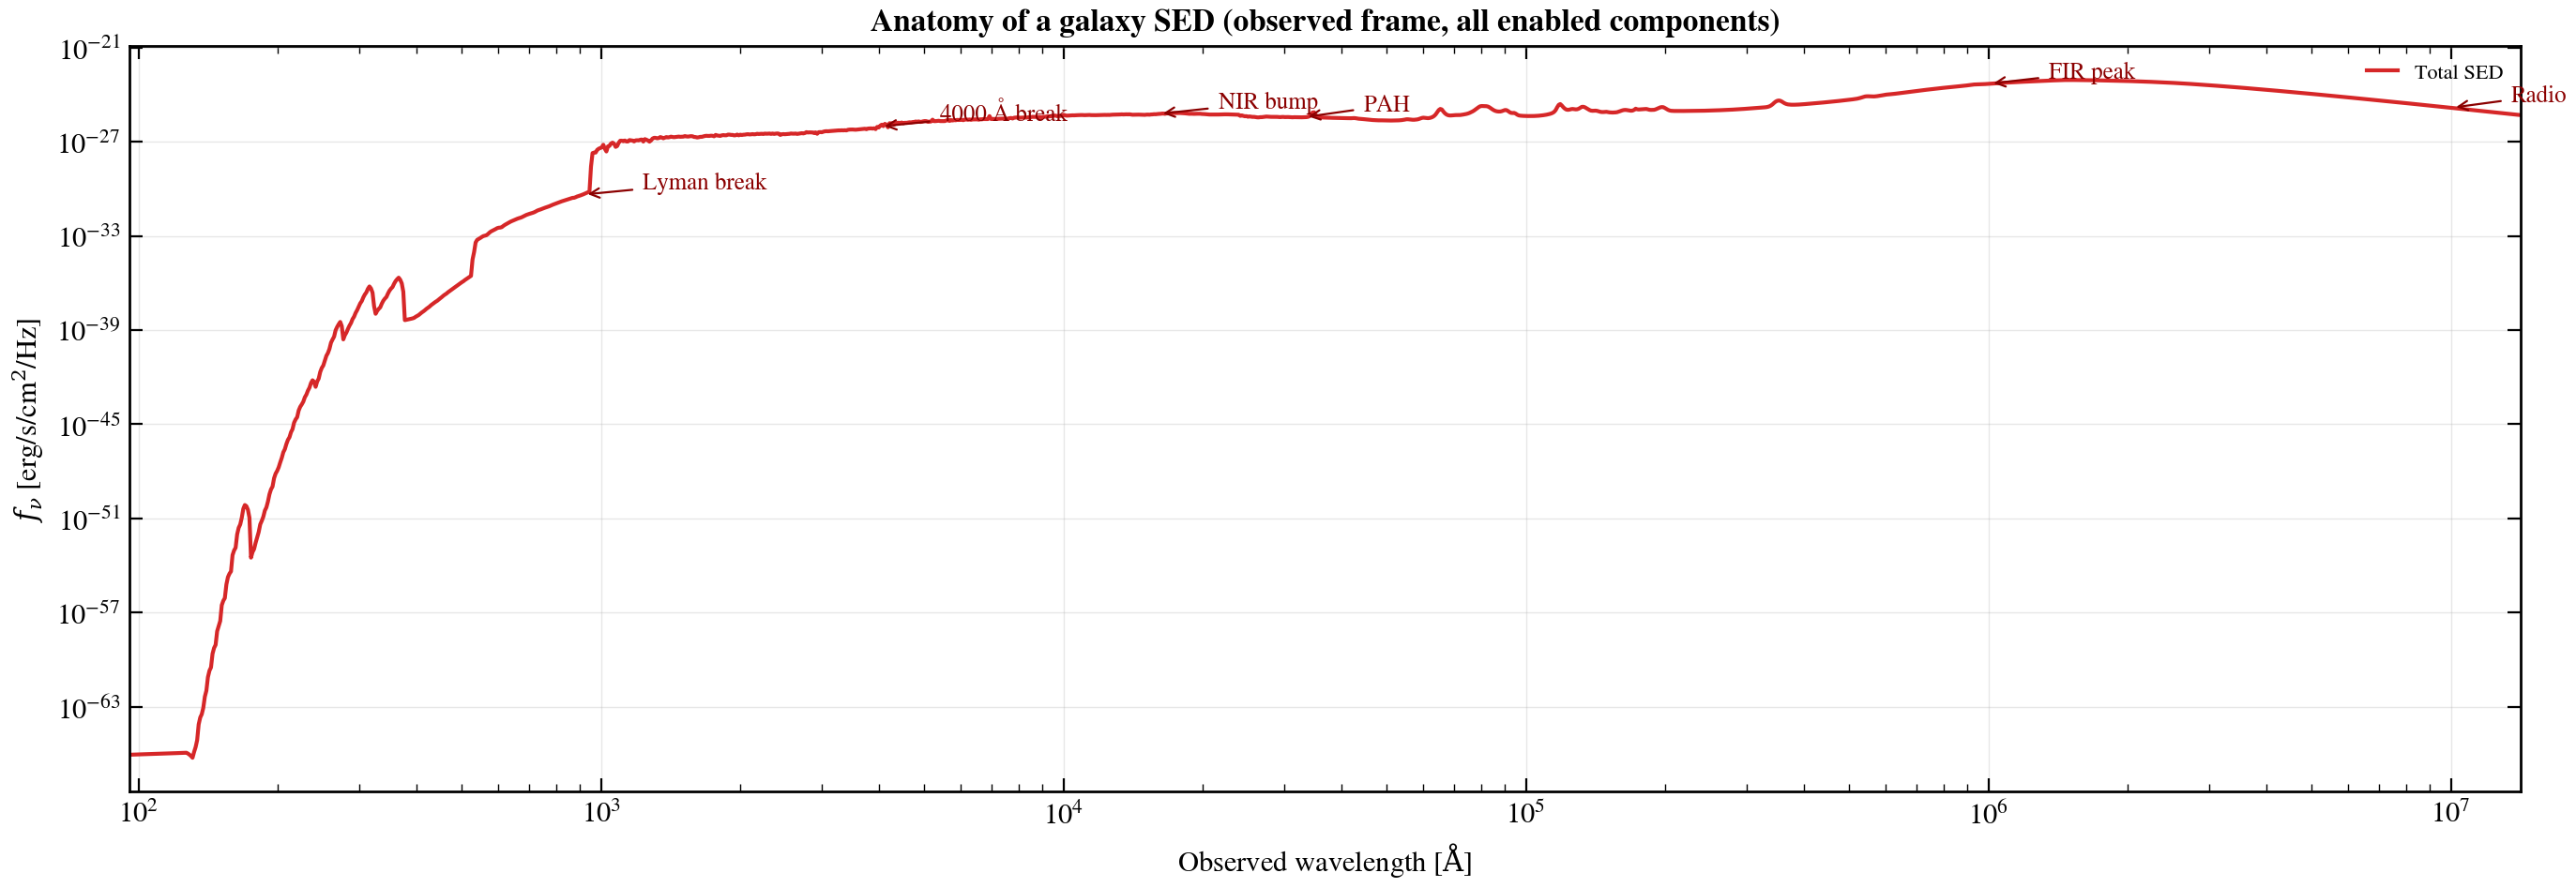

→ Next: build the SED in steps using separate forward models (same SSP, toggled modules).


In [3]:
wave_obs = jnp.logspace(0.5, 7.15, 2000)
sed_total = model_full.predict_spectrum(params, wave_obs)

fig, ax = plt.subplots(figsize=(14, 5))
w = np.array(wave_obs)
s = np.array(sed_total)
ok = np.isfinite(s) & (s > 0)
ax.loglog(w[ok], s[ok], color=COLORS.get("model", "C0"), lw=1.5, label="Total SED")

features = {
    20: "Soft X-ray",
    912: "Lyman break",
    4000: "4000 Å break",
    1.6e4: "NIR bump",
    3.3e4: "PAH",
    100e4: "FIR peak",
    1e7: "Radio",
}
for wave_feature, label in features.items():
    if w[ok][0] < wave_feature < w[ok][-1]:
        sed_at = float(np.interp(wave_feature, w[ok], s[ok]))
        ax.annotate(
            label,
            xy=(wave_feature, sed_at),
            xytext=(wave_feature * 1.35, sed_at * 2.5),
            fontsize=9,
            color="darkred",
            arrowprops=dict(arrowstyle="->", color="darkred", lw=0.8),
        )

ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]", fontsize=11)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=11)
ax.set_title(
    "Anatomy of a galaxy SED (observed frame, all enabled components)",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlim(float(w[ok].min()), float(w[ok].max()))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "01_sed_anatomy_full.png"), dpi=150, bbox_inches="tight")
plt.show()

print("→ Next: build the SED in steps using separate forward models (same SSP, toggled modules).")

## Section 2: Building the SED one component at a time

We use **several** `SEDModel` instances with different modules enabled, each time
calling **`predict_spectrum`** on the same wavelength grid. This avoids private
component hooks and stays on the supported public API.

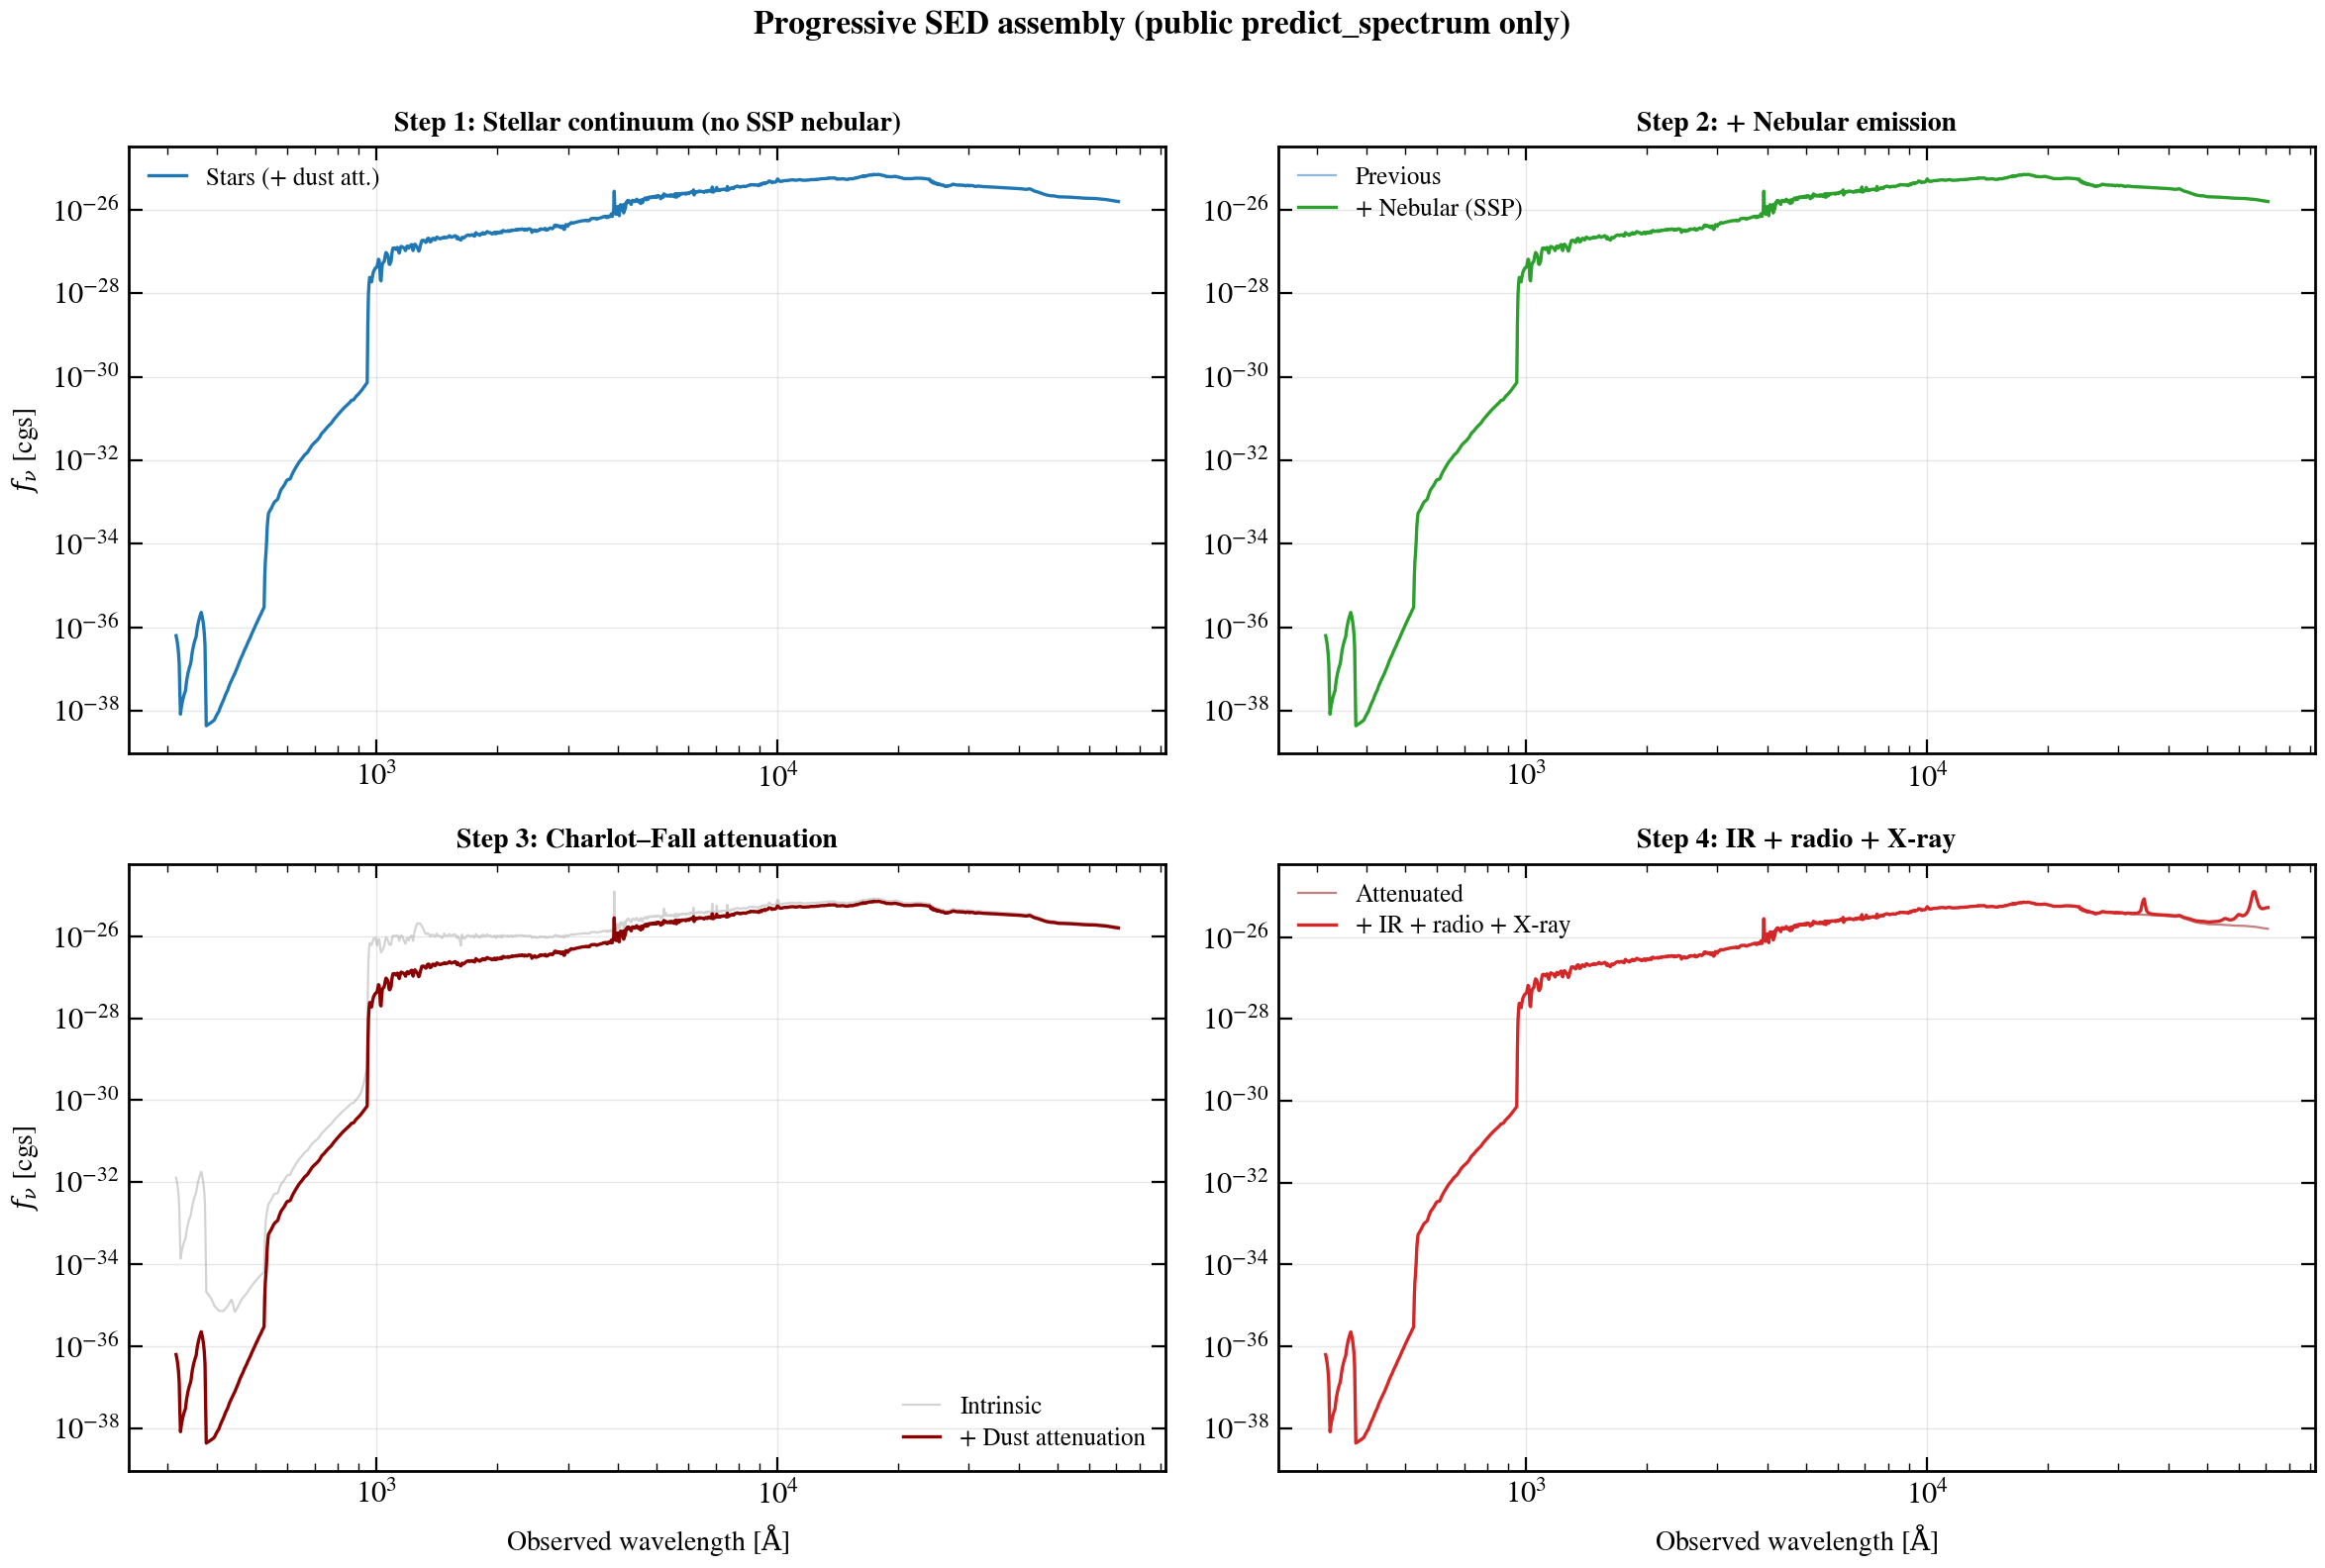

In [4]:
wave_vis = jnp.logspace(2.5, 4.85, 1500)

# Stellar + dust attenuation only (no nebular, no IR/radio/X-ray)
spec_stars = Parameters(**_sfh_dust_kwargs(), nebular_ssp=False)
model_stars = SEDModel(spec_stars, ssp_data, observation=None)
params_s = spec_stars.sample(jax.random.PRNGKey(42))
sed_stars_only = model_stars.predict_spectrum(params_s, wave_vis)

# + Nebular (baked into SSP)
spec_neb = Parameters(**_sfh_dust_kwargs(), nebular_ssp=True)
model_neb = SEDModel(spec_neb, ssp_data, observation=None)
params_n = spec_neb.sample(jax.random.PRNGKey(42))
sed_stars_nebular = model_neb.predict_spectrum(params_n, wave_vis)

# Intrinsic (no diffuse dust) vs attenuated stellar+nebular
params_no_dust = {
    **params_n,
    "dust_tau_bc": jnp.array(0.0),
    "dust_tau_diff": jnp.array(0.0),
}
sed_no_dust = model_neb.predict_spectrum(params_no_dust, wave_vis)
sed_with_atten = model_neb.predict_spectrum(params_n, wave_vis)

# + Dust IR + radio + X-ray (full)
sed_complete = model_full.predict_spectrum(params, wave_vis)

wv = np.array(wave_vis)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.loglog(
    wv, np.array(sed_stars_only), color=COLORS["seq"][2], lw=1.2, label="Stars (+ dust att.)"
)
ax.set_ylabel(r"$f_\nu$ [cgs]", fontsize=10)
ax.set_title("Step 1: Stellar continuum (no SSP nebular)", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.loglog(
    wv, np.array(sed_stars_only), color=COLORS["seq"][2], lw=0.8, alpha=0.5, label="Previous"
)
ax.loglog(wv, np.array(sed_stars_nebular), color=COLORS["seq"][3], lw=1.2, label="+ Nebular (SSP)")
ax.set_title("Step 2: + Nebular emission", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.loglog(wv, np.array(sed_no_dust), color=COLORS["seq"][1], lw=0.8, alpha=0.5, label="Intrinsic")
ax.loglog(wv, np.array(sed_with_atten), color="darkred", lw=1.2, label="+ Dust attenuation")
ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]", fontsize=10)
ax.set_ylabel(r"$f_\nu$ [cgs]", fontsize=10)
ax.set_title("Step 3: Charlot–Fall attenuation", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.loglog(wv, np.array(sed_with_atten), color="darkred", lw=0.8, alpha=0.5, label="Attenuated")
ax.loglog(wv, np.array(sed_complete), color=COLORS["seq"][4], lw=1.2, label="+ IR + radio + X-ray")
ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]", fontsize=10)
ax.set_title("Step 4: IR + radio + X-ray", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.suptitle(
    "Progressive SED assembly (public predict_spectrum only)",
    fontsize=12,
    fontweight="bold",
    y=1.0,
)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "01_sed_anatomy_components.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 3: The same galaxy at different redshifts

We only change `redshift` in the parameter dict and evaluate on an
observed-frame grid `λ_obs = λ_rest (1+z)`. Luminosity distance and IGM
handling are applied inside `predict_spectrum`—do **not** apply an extra
manual `(1+z)^{-2}` factor.

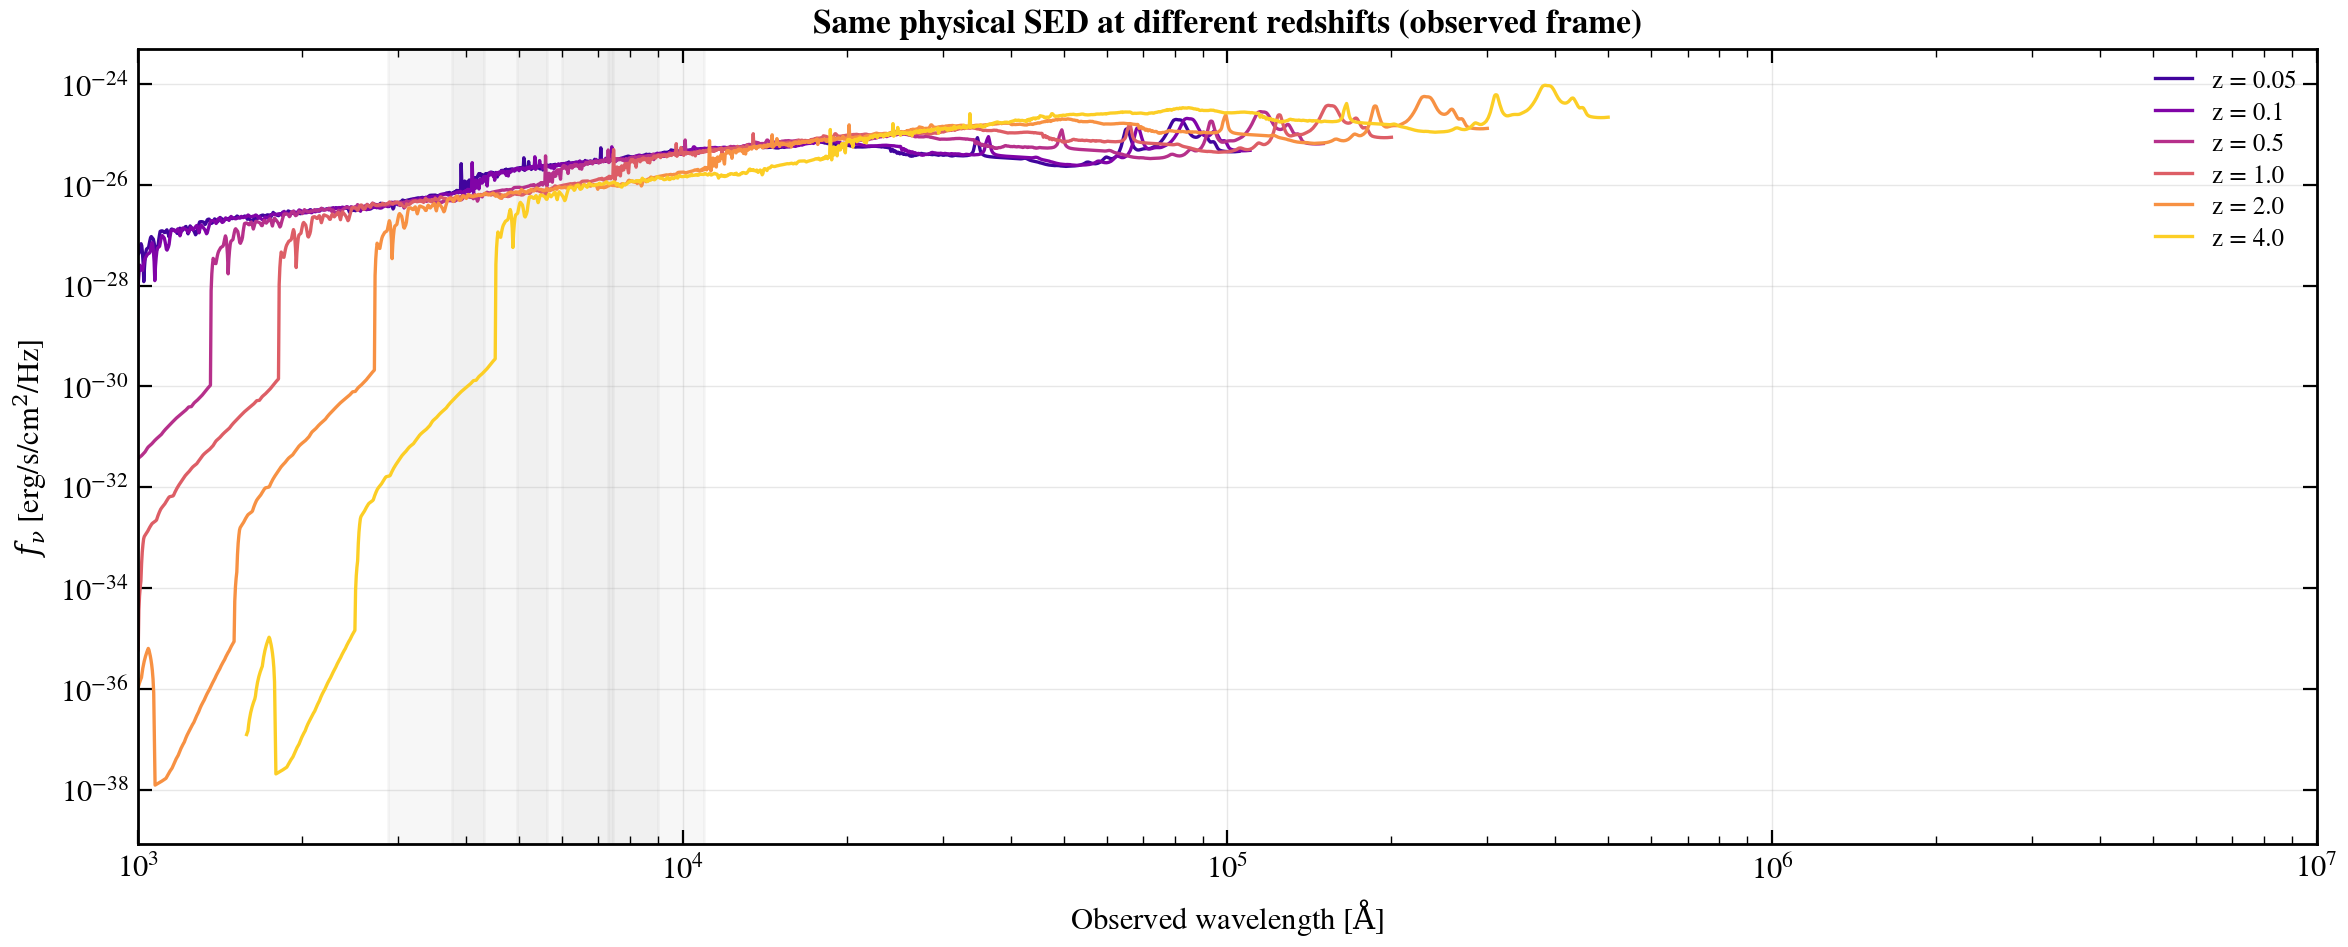

→ Next spine notebook: explore the allowed SFH shapes (`02_sfh_gallery.py`).


In [5]:
wave_rest = jnp.logspace(2.5, 5.0, 2000)
redshifts = [0.05, 0.1, 0.5, 1.0, 2.0, 4.0]
colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(redshifts)))

fig, ax = plt.subplots(figsize=(12, 5))

for z, col in zip(redshifts, colors_z):
    wave_obs_z = wave_rest * (1.0 + z)
    params_z = {**params, "redshift": jnp.array(z)}
    sed_z = model_full.predict_spectrum(params_z, wave_obs_z)
    ax.loglog(np.array(wave_obs_z), np.array(sed_z), color=col, lw=1.2, label=f"z = {z}")

ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]", fontsize=11)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=11)
ax.set_title(
    "Same physical SED at different redshifts (observed frame)", fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(1e3, 1e7)

sdss_bands = {"u": 3600, "g": 4700, "r": 6200, "i": 7500, "z": 9100}
for _band_name, band_center in sdss_bands.items():
    ax.axvspan(band_center * 0.8, band_center * 1.2, alpha=0.06, color="gray")

fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "01_sed_anatomy_redshift.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 3b: IGM transmission (high-$z$ caveat)

The plots above use the full pipeline's redshift handling. **Separately**, the
intergalactic medium suppresses observed flux blueward of the Lyman series
(Inoue+2014). `igm_transmission(wave_obs, z)` expects **observed-frame**
wavelengths in Å — the same convention as photometry through bandpasses.
See `06_multiwavelength_gallery.py` for a longer tour.

In [ ]:
from tengri.models.igm import igm_transmission

wave_obs_igm = jnp.linspace(500.0, 25000.0, 2000)
fig, ax = plt.subplots(figsize=(9, 3.5))
for z, c in zip([1.0, 3.0, 6.0], plt.cm.plasma([0.2, 0.55, 0.85])):
    t = igm_transmission(wave_obs_igm, z)
    ax.plot(np.array(wave_obs_igm), np.array(t), color=c, lw=1.2, label=f"z = {z:.0f}")
ax.set_xscale("log")
ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$T_{\rm IGM}$")
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False)
ax.set_title("IGM transmission (Inoue+2014) — illustration only")
fig.tight_layout()
plt.show()

## Section 4: Optical spectrum — baked-in nebular only (fit-safe)

For MAP / MCMC / VI on an optical spectrum, build `SEDModel` with
``spec_baked_optical`` and `Observation(spectroscopy=Spectroscopy(...))`.
Omitting IR/radio/X-ray matches the information in the data and avoids
invalid Gaussian likelihoods from mis-sized or non-finite predictions.

In [ ]:
WAVE_FIT = jnp.linspace(3800.0, 9200.0, 200)
obs_optical = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_FIT))
sed_optical = SEDModel(spec_baked_optical, ssp_data, observation=obs_optical)

_key_opt = jax.random.PRNGKey(42)
params_optical = spec_baked_optical.sample(_key_opt)
mock_optical = sed_optical.mock_spectrum(
    params_optical, WAVE_FIT, snr=40.0, key=jax.random.fold_in(_key_opt, 1)
)

# Use the high-level Model.from_config() API for fitting. Short-name priors
# (log_peak_sfr, logzsol, etc.) are auto-expanded to their full prefixed names.
# wave_obs is passed directly so Model builds the Observation internally.
model_fit = Model.from_config(
    ssp=SSP_PATH,
    sfh="tsnorm",
    redshift=0.05,
    wave_obs=WAVE_FIT,
    priors=dict(
        log_peak_sfr=Uniform(-1.0, 3.0),
        peak_lbt_gyr=Uniform(0.5, 10.0),
        width_gyr=Uniform(0.2, 6.0),
        logzsol=Uniform(-2.0, 0.4),
        dust_tau_bc=Uniform(0.0, 3.0),
        dust_tau_diff=Uniform(0.0, 1.5),
    ),
)
result_optical = model_fit.fit(
    spectrum=(mock_optical.flux_obs, mock_optical.noise),
    method="map",
    n_steps=300,
    verbose=False,
)

pred_truth = sed_optical.predict_spectrum(params_optical, WAVE_FIT)
resid_sigma = (mock_optical.flux_obs - pred_truth) / mock_optical.noise
log_gauss_truth = float(-0.5 * jnp.sum(resid_sigma**2))
print(
    "Optical-only model: log (Gaussian) at generating params =",
    log_gauss_truth,
    "(finite:",
    jnp.isfinite(log_gauss_truth).item(),
    ")",
)

print(
    "→ Next: SFH gallery `02_sfh_gallery.py`, dust `03_dust_gallery.py`, multi-λ `06_multiwavelength_gallery.py`."
)